# Simulação de Suspensão Ativa de Meio-Carro

Estudo inspirado em Taghirad & Esmailzadeh (1997) comparando configurações passiva, LQR e LQG para um modelo half-car.

> Felipe Andrade Garcia Tommaselli- 11800910

## Objetivo

Integrar modelagem e controle em Python para avaliar conforto e handling com diferentes estratégias de suspensão.

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal, linalg
from scipy.special import erf, erfinv
import random

np.random.seed(42)
random.seed(42)


O veículo é modelado com seis graus de liberdade principais: bounce e pitch do corpo, deflexões dos pneus dianteiro e traseiro, e deslocamentos dos passageiros.

O vetor de estados reúne posições e velocidades como `[x, ẋ, θ, θ̇, x_t1, ẋ_t1, x_t2, ẋ_t2, x_p1, ẋ_p1, x_p2, ẋ_p2]ᵀ`.

In [9]:
# Parâmetros do veículo (SI)
I_p = 3443.05
m = 1794.4
m_p1 = 75.0
m_p2 = 75.0
m_t1 = 87.15
m_t2 = 140.04

# Rigidez
k_1 = 66824.2
k_2 = 18615.0
k_p1 = 14000.0
k_p2 = 14000.0
k_t1 = 101115.0
k_t2 = 101115.0

# Amortecimento
c_1 = 1190.0
c_2 = 1000.0
c_p1 = 50.2
c_p2 = 62.1
c_t1 = 14.6
c_t2 = 14.6

# Geometria
b_1 = 1.271
b_2 = 1.713
d_1 = 0.481
d_2 = 1.313


As equações dinâmicas de Taghirad & Esmailzadeh (1997) descrevem o acoplamento entre corpo, pneus e passageiros. O modelo em espaço de estados é representado por `ẋ = Ax + Bu + Gw`, com entradas `u = [f₁, f₂]ᵀ` e distúrbios `w` associados ao perfil da estrada.

In [10]:
def create_half_car_model():
    """Retorna as matrizes A, B e G do modelo half-car."""

    n_states = 12
    n_inputs = 2
    n_disturbances = 4

    A = np.zeros((n_states, n_states))
    B = np.zeros((n_states, n_inputs))
    G = np.zeros((n_states, n_disturbances))

    A[0, 1] = 1.0
    A[2, 3] = 1.0
    A[4, 5] = 1.0
    A[6, 7] = 1.0
    A[8, 9] = 1.0
    A[10, 11] = 1.0

    A[1, 0] = -(k_1 + k_2 + k_p1 + k_p2) / m
    A[1, 1] = -(c_1 + c_2 + c_p1 + c_p2) / m
    A[1, 2] = -(k_1*b_1 - k_2*b_2 + k_p1*d_1 - k_p2*d_2) / m
    A[1, 3] = -(c_1*b_1 - c_2*b_2 + c_p1*d_1 - c_p2*d_2) / m
    A[1, 4] = k_1 / m
    A[1, 5] = c_1 / m
    A[1, 6] = k_2 / m
    A[1, 7] = c_2 / m
    A[1, 8] = k_p1 / m
    A[1, 9] = c_p1 / m
    A[1, 10] = k_p2 / m
    A[1, 11] = c_p2 / m

    A[3, 0] = -(k_1*b_1 - k_2*b_2 + k_p1*d_1 - k_p2*d_2) / I_p
    A[3, 1] = -(c_1*b_1 - c_2*b_2 + c_p1*d_1 - c_p2*d_2) / I_p
    A[3, 2] = -(k_1*b_1**2 + k_2*b_2**2 + k_p1*d_1**2 + k_p2*d_2**2) / I_p
    A[3, 3] = -(c_1*b_1**2 + c_2*b_2**2 + c_p1*d_1**2 + c_p2*d_2**2) / I_p
    A[3, 4] = k_1*b_1 / I_p
    A[3, 5] = c_1*b_1 / I_p
    A[3, 6] = -k_2*b_2 / I_p
    A[3, 7] = -c_2*b_2 / I_p
    A[3, 8] = k_p1*d_1 / I_p
    A[3, 9] = c_p1*d_1 / I_p
    A[3, 10] = -k_p2*d_2 / I_p
    A[3, 11] = -c_p2*d_2 / I_p

    A[5, 0] = k_1 / m_t1
    A[5, 1] = c_1 / m_t1
    A[5, 2] = k_1*b_1 / m_t1
    A[5, 3] = c_1*b_1 / m_t1
    A[5, 4] = -(k_1 + k_t1) / m_t1
    A[5, 5] = -(c_1 + c_t1) / m_t1

    A[7, 0] = k_2 / m_t2
    A[7, 1] = c_2 / m_t2
    A[7, 2] = -k_2*b_2 / m_t2
    A[7, 3] = -c_2*b_2 / m_t2
    A[7, 6] = -(k_2 + k_t2) / m_t2
    A[7, 7] = -(c_2 + c_t2) / m_t2

    A[9, 0] = k_p1 / m_p1
    A[9, 1] = c_p1 / m_p1
    A[9, 2] = k_p1*d_1 / m_p1
    A[9, 3] = c_p1*d_1 / m_p1
    A[9, 8] = -k_p1 / m_p1
    A[9, 9] = -c_p1 / m_p1

    A[11, 0] = k_p2 / m_p2
    A[11, 1] = c_p2 / m_p2
    A[11, 2] = -k_p2*d_2 / m_p2
    A[11, 3] = -c_p2*d_2 / m_p2
    A[11, 10] = -k_p2 / m_p2
    A[11, 11] = -c_p2 / m_p2

    B[1, 0] = 1.0 / m
    B[1, 1] = 1.0 / m
    B[3, 0] = b_1 / I_p
    B[3, 1] = -b_2 / I_p
    B[5, 0] = -1.0 / m_t1
    B[7, 1] = -1.0 / m_t2

    G[5, 0] = k_t1 / m_t1
    G[5, 2] = c_t1 / m_t1
    G[7, 1] = k_t2 / m_t2
    G[7, 3] = c_t2 / m_t2

    return A, B, G


A rugosidade da estrada segue a ISO 8608, com PSD `G_q(n) = G_q(n₀) (n/n₀)^{-w}`. As classes A–D usam `G_q(n₀)` iguais a {16, 64, 256, 1024}×10⁻⁶ m³, `n₀ = 0.1` ciclos/m e expoente `w ≈ 2`.

In [11]:
def generate_iso_road_disturbance(time_vector, road_class='C', vehicle_speed=60/3.6):
    """Gera distúrbios de estrada conforme a ISO 8608."""

    iso_parameters = {
        'A': 16e-6,
        'B': 64e-6,
        'C': 256e-6,
        'D': 1024e-6
    }

    print(f"Gerando distúrbios de estrada ISO classe {road_class}")
    print(f"Velocidade do veículo: {vehicle_speed*3.6:.1f} km/h")

    if road_class not in iso_parameters:
        road_class = 'C'
        print(f"Classe não reconhecida, usando classe C (ruim)")

    G_q0 = iso_parameters[road_class]
    n0 = 0.1
    w = 2.0

    dt = time_vector[1] - time_vector[0]
    fs = 1.0 / dt
    N = len(time_vector)

    freq = np.fft.fftfreq(N, dt)

    spatial_freq = np.abs(freq) / vehicle_speed

    spatial_freq[spatial_freq == 0] = 1e-10

    G_q = G_q0 * (spatial_freq / n0)**(-w)

    phases = 2 * np.pi * np.random.rand(N)

    spectrum = np.sqrt(G_q * fs) * np.exp(1j * phases)
    spectrum[0] = 0

    spectrum[N//2+1:] = np.conj(spectrum[1:N//2][::-1])

    road_profile = np.real(np.fft.ifft(spectrum))

    correlation = 0.7
    left_profile = road_profile

    noise = np.random.normal(0, np.std(road_profile) * np.sqrt(1 - correlation**2), N)
    right_profile = correlation * road_profile + noise

    left_velocity = np.gradient(left_profile, dt)
    right_velocity = np.gradient(right_profile, dt)

    print(f"Desvio padrão do perfil: {np.std(left_profile)*1000:.2f} mm")

    return left_profile, right_profile, left_velocity, right_velocity


O LQR minimiza `J = ∫₀^∞ (xᵀQx + uᵀRu) dt`, com ganho `K = R⁻¹BᵀP` e `P` solução da ARE. No método convencional (CM) escolhemos `Q` para estados relevantes; no método dependente da aceleração (ADM) acrescentamos `z = Vx` e um peso `S` elevado, obtendo `Q + VᵀSV`.

In [12]:
def design_lqr_controller(A, B, method='CM'):
    """Projeta o controlador LQR pelos métodos CM e ADM."""

    n_states = A.shape[0]
    n_inputs = B.shape[1]

    print(f"\nProjetando controlador LQR - Método: {method}")

    R = np.eye(n_inputs) * 1e-3

    Q = np.zeros((n_states, n_states))

    if method == 'CM':

        Q[0, 0] = 1000
        Q[2, 2] = 1000

        Q[4, 4] = 100
        Q[6, 6] = 100

        Q[8, 8] = 5000
        Q[10, 10] = 5000

        Q[1, 1] = 10
        Q[3, 3] = 10
        Q[9, 9] = 50
        Q[11, 11] = 50

    elif method == 'ADM':

        Q[0, 0] = 1000
        Q[2, 2] = 1000
        Q[4, 4] = 100
        Q[6, 6] = 100
        Q[8, 8] = 5000
        Q[10, 10] = 5000
        Q[1, 1] = 10
        Q[3, 3] = 10
        Q[9, 9] = 50
        Q[11, 11] = 50


        V = np.zeros((2, n_states))

        V[0, 0] = k_p1 / m_p1
        V[0, 1] = c_p1 / m_p1
        V[0, 2] = k_p1*d_1 / m_p1
        V[0, 3] = c_p1*d_1 / m_p1
        V[0, 8] = -k_p1 / m_p1
        V[0, 9] = -c_p1 / m_p1

        V[1, 0] = k_p2 / m_p2
        V[1, 1] = c_p2 / m_p2
        V[1, 2] = -k_p2*d_2 / m_p2
        V[1, 3] = -c_p2*d_2 / m_p2
        V[1, 10] = -k_p2 / m_p2
        V[1, 11] = -c_p2 / m_p2

        S = np.eye(2) * 1e6

        Q = Q + V.T @ S @ V


    try:
        P = linalg.solve_continuous_are(A, B, Q, R)
        K = linalg.inv(R) @ B.T @ P

        A_cl = A - B @ K
        eigenvalues = np.linalg.eigvals(A_cl)

        print(f"Ganhos do controlador K: {K.shape}")
        print(f"Máximo ganho: {np.max(np.abs(K)):.2e}")

        return K, P, Q, R

    except Exception as e:
        print(f"Erro ao resolver ARE: {e}")
        return np.zeros((n_inputs, n_states)), np.eye(n_states), Q, R


TEORIA DO OBSERVADOR LQG:

O filtro de Kalman contínuo combina o modelo com medições ruidosas `y = Cx + v` para estimar os estados e fornecer os ganhos `L` usados no controlador.

In [13]:
def design_kalman_observer(A, B, method='CM'):
    """Projeta o filtro de Kalman contínuo para o modelo."""

    n_states = A.shape[0]



    n_outputs = 4
    C = np.zeros((n_outputs, n_states))

    C[0, 0] = 1.0
    C[0, 2] = b_1
    C[0, 4] = -1.0

    C[1, 0] = 1.0
    C[1, 2] = -b_2
    C[1, 6] = -1.0

    C[2, 0] = 1.0
    C[2, 2] = d_1
    C[2, 8] = -1.0

    C[3, 0] = 1.0
    C[3, 2] = -d_2
    C[3, 10] = -1.0

    print(f"Matriz de saída C: {C.shape} (sensores)")

    W = np.eye(n_states) * 1e-6

    W[4, 4] = 1e-3
    W[6, 6] = 1e-3
    W[5, 5] = 1e-4
    W[7, 7] = 1e-4

    V = np.eye(n_outputs) * 1e-4


    try:
        P_obs = linalg.solve_continuous_are(A.T, C.T, W, V)
        L = P_obs @ C.T @ linalg.inv(V)

        A_obs = A - L @ C
        eigenvalues_obs = np.linalg.eigvals(A_obs)


        print(f"Ganhos do observador L: {L.shape}")

        return L, C, W, V

    except Exception as e:
        print(f"Erro ao projetar observador: {e}")
        return np.zeros((n_states, n_outputs)), C, W, V


In [14]:


def simulate_system():
    """Executa a simulação passiva do modelo Half-Car."""

    print("INICIANDO SIMULAÇÃO PASSIVA DO SISTEMA")

    t_final = 20.0
    dt = 0.01
    time = np.arange(0, t_final, dt)
    N = len(time)

    print(f"Tempo de simulação: {t_final} s")
    print(f"Passo de integração: {dt} s")
    print(f"Número de pontos: {N}")

    A, B, G = create_half_car_model()

    road_left, road_right, road_vel_left, road_vel_right = generate_iso_road_disturbance(
        time, road_class='C', vehicle_speed=60/3.6)

    w = np.vstack([road_left, road_right, road_vel_left, road_vel_right])

    x0 = np.zeros(A.shape[0])

    x_passive = np.zeros((A.shape[0], N))
    x_passive[:, 0] = x0

    for k in range(N-1):
        x_dot = A @ x_passive[:, k] + G @ w[:, k]
        x_passive[:, k+1] = x_passive[:, k] + dt * x_dot

    def compute_passenger_accelerations(x_states):
        """Calcula acelerações dos passageiros a partir dos estados"""
        x_pos = x_states[0, :]
        x_vel = x_states[1, :]
        theta = x_states[2, :]
        theta_dot = x_states[3, :]
        x_p1 = x_states[8, :]
        x_p1_dot = x_states[9, :]
        x_p2 = x_states[10, :]
        x_p2_dot = x_states[11, :]

        acc_p1 = (k_p1/m_p1) * (x_pos + d_1*theta - x_p1) + \
                  (c_p1/m_p1) * (x_vel + d_1*theta_dot - x_p1_dot)

        acc_p2 = (k_p2/m_p2) * (x_pos - d_2*theta - x_p2) + \
                  (c_p2/m_p2) * (x_vel - d_2*theta_dot - x_p2_dot)

        return acc_p1, acc_p2

    acc_p1_passive, acc_p2_passive = compute_passenger_accelerations(x_passive)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle('Respostas Temporais - Sistema de Suspensão Passiva Half-Car' +
                'Taghirad & Esmailzadeh (1997)', fontsize=16, fontweight='bold')

    ax = axes[0]
    ax.plot(time, acc_p1_passive, 'r-', linewidth=1.5, label='Passivo')
    ax.set_xlabel('Tempo (s)')
    ax.set_ylabel('Aceleração (m/s²)')
    ax.set_title('Aceleração Passageiro Dianteiro')
    ax.legend()

    ax = axes[1]
    ax.plot(time, x_passive[0, :]*1000, 'r-', linewidth=1.5, label='Passivo')
    ax.set_xlabel('Tempo (s)')
    ax.set_ylabel('Deslocamento (mm)')
    ax.set_title('Bounce do Corpo')
    ax.legend()

    ax = axes[2]
    ax.plot(time, road_left*1000, 'k-', linewidth=1.0, label='Entrada Dianteira')
    ax.plot(time, road_right*1000, 'k--', linewidth=1.0, label='Entrada Traseira')
    ax.set_xlabel('Tempo (s)')
    ax.set_ylabel('Elevação (mm)')
    ax.set_title('Perfil da Estrada (ISO Classe C)')
    ax.legend()

    for ax in axes:
        ax.grid(True, alpha=0.3)

    fig.tight_layout(rect=[0, 0.03, 1, 0.95])
    fig.savefig('respostas_temporais_suspensao.png', dpi=300, bbox_inches='tight')
    plt.show()

    plt.figure(figsize=(15, 10))
    plt.suptitle('Análise de Frequência - Sistema de Suspensão Passiva Half-Car' +
                 'Taghirad & Esmailzadeh (1997)', fontsize=14, fontweight='bold')

    nperseg = min(1024, N//8)

    plt.subplot(2, 3, 1)
    f1, Pxx1_passive = signal.welch(acc_p1_passive, 1/dt, nperseg=nperseg)
    plt.semilogy(f1, Pxx1_passive, 'r-', linewidth=1.5, label='Passivo')
    plt.xlabel('Frequência (Hz)')
    plt.ylabel('PSD (m²/s⁴/Hz)')
    plt.title('PSD - Aceleração Passageiro Dianteiro')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.xlim([0.1, 20])

    plt.subplot(2, 3, 2)
    f2, Pxx2_passive = signal.welch(acc_p2_passive, 1/dt, nperseg=nperseg)
    plt.semilogy(f2, Pxx2_passive, 'r-', linewidth=1.5, label='Passivo')
    plt.xlabel('Frequência (Hz)')
    plt.ylabel('PSD (m²/s⁴/Hz)')
    plt.title('PSD - Aceleração Passageiro Traseiro')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.xlim([0.1, 20])

    plt.subplot(2, 3, 3)
    f3, Pxx3_passive = signal.welch(x_passive[0, :], 1/dt, nperseg=nperseg)
    plt.semilogy(f3, Pxx3_passive, 'r-', linewidth=1.5, label='Passivo')
    plt.xlabel('Frequência (Hz)')
    plt.ylabel('PSD (m²/Hz)')
    plt.title('PSD - Bounce do Corpo')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.xlim([0.1, 20])

    plt.subplot(2, 3, 4)
    f4, Pxx4_passive = signal.welch(x_passive[2, :], 1/dt, nperseg=nperseg)
    plt.semilogy(f4, Pxx4_passive, 'r-', linewidth=1.5, label='Passivo')
    plt.xlabel('Frequência (Hz)')
    plt.ylabel('PSD (rad²/Hz)')
    plt.title('PSD - Pitch do Corpo')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.xlim([0.1, 20])

    plt.subplot(2, 3, 5)
    f5, Pxx5_passive = signal.welch(x_passive[4, :], 1/dt, nperseg=nperseg)
    plt.semilogy(f5, Pxx5_passive, 'r-', linewidth=1.5, label='Passivo')
    plt.xlabel('Frequência (Hz)')
    plt.ylabel('PSD (m²/Hz)')
    plt.title('PSD - Deflexão Pneu Dianteiro')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.xlim([0.1, 20])

    plt.subplot(2, 3, 6)
    f6, Pxx6_passive = signal.welch(road_left, 1/dt, nperseg=nperseg)
    plt.semilogy(f6, Pxx6_passive, 'k-', linewidth=1.5, label='Perfil Estrada')
    plt.xlabel('Frequência (Hz)')
    plt.ylabel('PSD (m²/Hz)')
    plt.title('PSD - Entrada ISO Classe C')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.xlim([0.1, 20])

    plt.tight_layout()
    plt.savefig('respostas_frequencia_suspensao.png', dpi=300, bbox_inches='tight')
    plt.show()

    return 


## Execução

Rode a célula abaixo para executar a simulação completa e visualizar os resultados. Dependendo da sua máquina, a execução pode levar alguns segundos.

INICIANDO SIMULAÇÃO PASSIVA DO SISTEMA
Tempo de simulação: 20.0 s
Passo de integração: 0.01 s
Número de pontos: 2000
Gerando distúrbios de estrada ISO classe C
Velocidade do veículo: 60.0 km/h
Desvio padrão do perfil: 4.84 mm


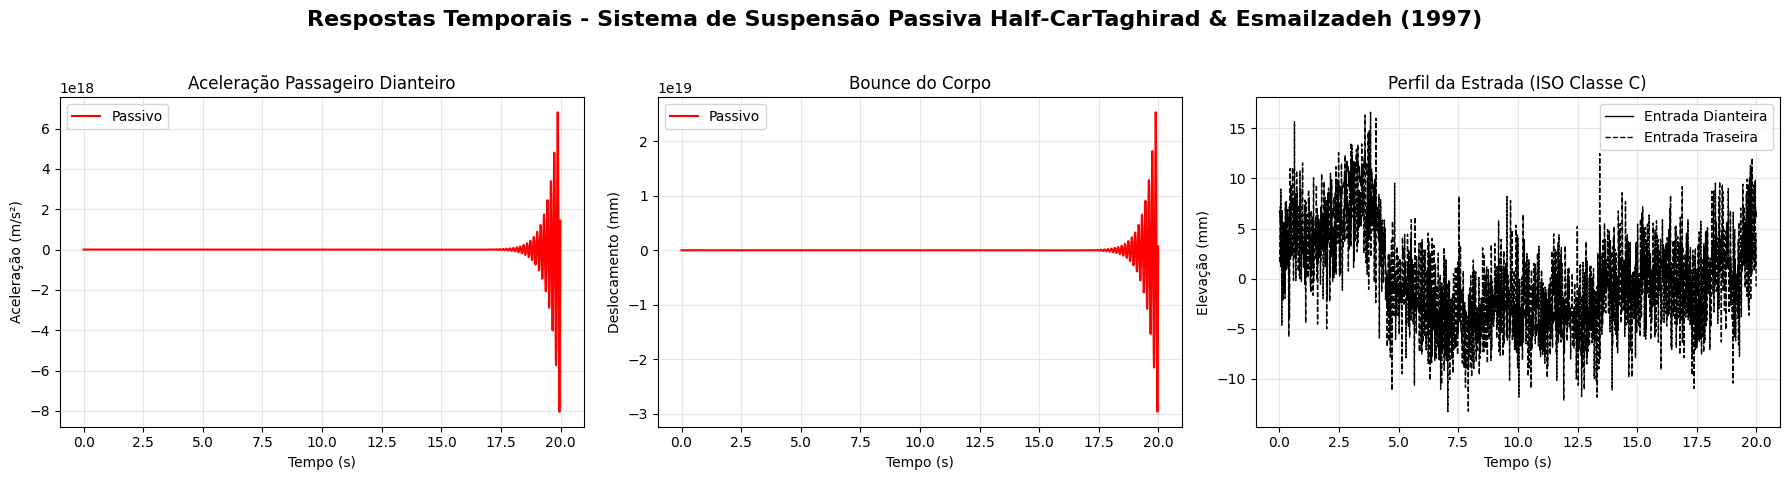

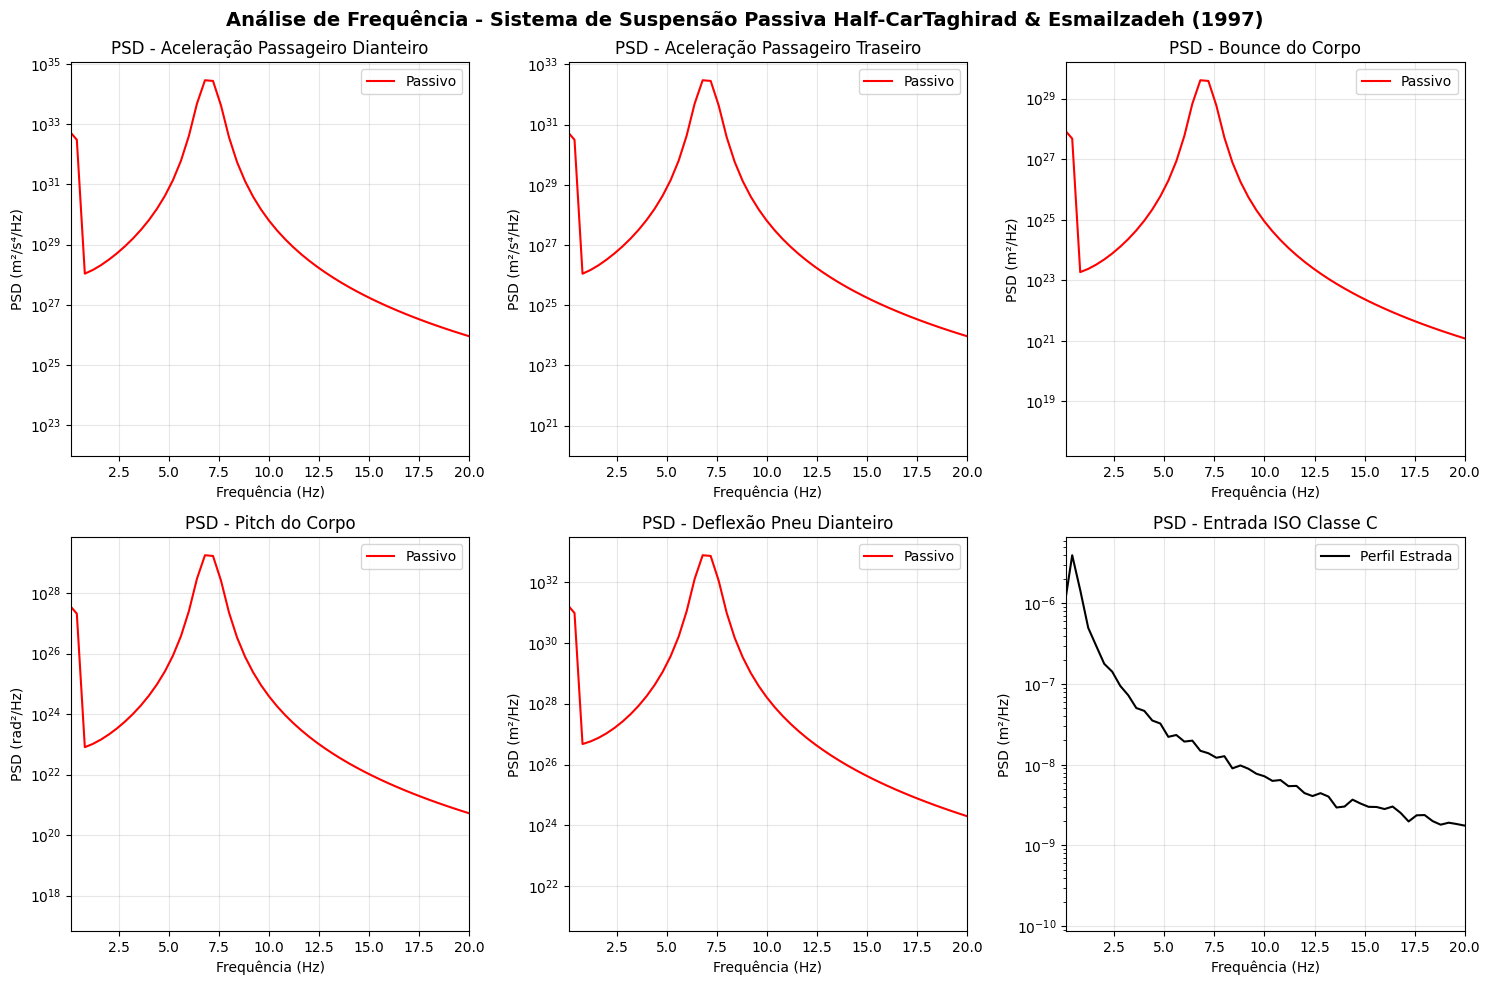

In [15]:
results = simulate_system()